<a href="https://colab.research.google.com/github/ebonyvan-web/capstone-exercise/blob/main/Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

url = " https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst"
df = pd.read_csv(url)
df.head()



,mmsi,base_date_time,longitude,latitude,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver
0,367793030,2025-01-08 00:00:00,-122.40506,47.68588,4.6,155.5,NaN,WN1622SL,NaN,WDJ5962,37.0,NaN,10.0,3.0,NaN,NaN,B
1,338160209,2025-01-08 00:00:00,-119.69199,34.40719,0.0,106.3,NaN,WESTERLY,NaN,NaN,36.0,NaN,11.0,4.0,NaN,NaN,B
2,266283000,2025-01-08 00:00:01,-74.24126,38.41834,15.5,187.9,190.0,OBERON,IMO9377509,SKJF,70.0,0.0,237.0,32.0,9.1,70.0,A
3,368013620,2025-01-08 00:00:10,-74.04712,40.10181,0.0,252.3,NaN,MARKET PRICE,NaN,WDJ8153,30.0,NaN,17.0,6.0,NaN,NaN,B
4,368144150,2025-01-08 00:00:09,-119.22453,34.16235,0.0,169.6,NaN,SILENT LADY,NaN,WDL5759,37.0,NaN,12.0,5.0,NaN,NaN,B


In [6]:
df['base_date_time'] = pd.to_datetime(df['base_date_time'])
df = df.set_index('base_date_time')
df = df.sort_index()
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5929631 entries, 2025-01-08 00:00:00 to 2025-01-08 23:59:59
Data columns (total 16 columns):
 #   Column       Dtype  
---  ------       -----  
 0   mmsi         int64  
 1   longitude    float64
 2   latitude     float64
 3   sog          float64
 4   cog          float64
 5   heading      float64
 6   vessel_name  object 
 7   imo          object 
 8   call_sign    object 
 9   vessel_type  float64
 10  status       float64
 11  length       float64
 12  width        float64
 13  draft        float64
 14  cargo        float64
 15  transceiver  object 
dtypes: float64(11), int64(1), object(4)
memory usage: 769.1+ MB


In [7]:
df = df[df['sog'].notna()]
df.shape

(5917091, 16)

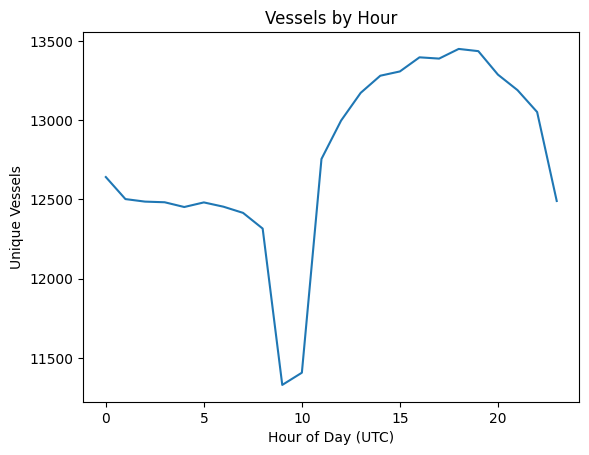

Most vessels at hour (UTC): 18
Least vessels at hour (UTC): 9


In [8]:
df['hour'] = df.index.hour
hourly_counts = df.groupby('hour')['mmsi'].nunique()

plt.figure()
hourly_counts.plot()
plt.xlabel("Hour of Day (UTC)")
plt.ylabel("Unique Vessels")
plt.title("Vessels by Hour")
plt.show()

max_hour = hourly_counts.idxmax()
min_hour = hourly_counts.idxmin()

print("Most vessels at hour (UTC):", max_hour)
print("Least vessels at hour (UTC):", min_hour)